# WQD7013 Assignment 1 - Member 3 and 4
**Tasks: B1, B2, B3, B4, E3, E4**

---

In [8]:
# Define variables for grouped comparison
num_var = "life_expectancy"
cat_var = "income_group"

# Select only the variables needed for B3
# Missing values are removed only for this analysis to ensure that comparisons are based on complete observations. This avoids distortion in summary statistics and visualisations.
b3_data = df[[cat_var, num_var]].dropna()

# Display number of usable observations
print("Number of observations used in B3:", len(b3_data))

Number of observations used in B3: 215


In [9]:
# Create grouped summary table

b3_summary = (
    b3_data
    .groupby(cat_var)[num_var]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        minimum="min",
        maximum="max"
    )
)

# Calculate Interquartile Range
# IQR = Q3 - Q1
b3_summary["IQR"] = b3_summary["q3"] - b3_summary["q1"]

# Sort groups by median life expectancy
b3_summary = b3_summary.sort_values("median", ascending=False)

# Display grouped summary table
b3_summary.round(2)

,count,mean,median,std,q1,q3,minimum,maximum,IQR
income_group,,,,,,,,,
High income,86,79.810,81.130,4.180,77.370,82.940,62.110,86.370,5.570
Upper middle income,54,73.810,74.010,3.730,71.530,77.030,63.710,81.040,5.500
Lower middle income,50,68.470,68.090,5.110,65.570,71.950,54.460,77.820,6.380
Low income,25,64.020,63.630,4.560,61.180,67.350,55.070,73.640,6.170


The table above reports the mean, median, standard deviation, IQR, minimum, and maximum life expectancy for each income group. The median and IQR are especially useful because they are less affected by extreme values than the mean and standard deviation.

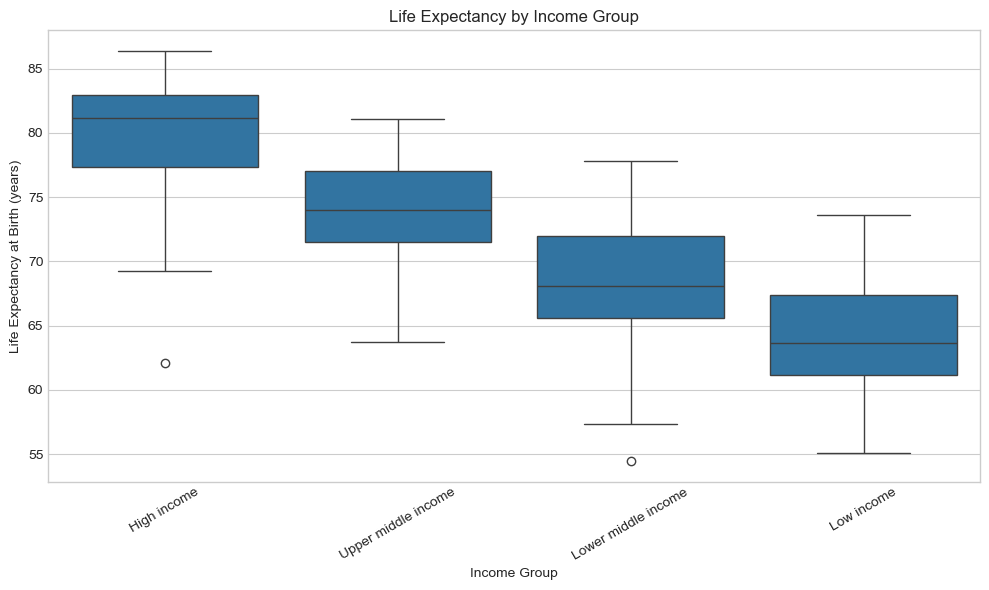

In [10]:
# Create side-by-side boxplot

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=b3_data,
    x=cat_var,
    y=num_var,
    order=b3_summary.index
)

plt.title("Life Expectancy by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Life Expectancy at Birth (years)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### B3. Interpretation and Justification

#### 1. Comparison of Groups (Centre, Spread, Shape, and Outliers)
* **Centre:** There is a definitive positive correlation between economic status and health outcomes. The **median** life expectancy drops progressively from **81.13 years** in High-income nations to **63.63 years** in Low income nations, a gap of 17.5 years.
* **Spread:** Lower middle income countries show the highest internal inequality with an **IQR of 6.38 years**, whereas High income countries are more tightly clustered (**IQR = 5.57 years**).
* **Shape:** High and Upper middle income groups exhibit left-skewness. This is confirmed by the noticeably longer lower whiskers and medians positioned toward the top of the boxes. In these groups, the mean is lower than the median (e.g., 79.81<81.13 for High income). Lower middle and Low income groups are right-skewed. This is visible because the median is positioned slightly lower in the box, meaning the upper half of the interquartile range is more stretched. This is supported by the fact that their means are higher than their medians (e.g., 64.02>63.63 for Low-income).
* **Outliers:** The boxplot identifies clear outliers in the High income and Lower middle income groups. These represent specific nations whose health outcomes are significantly lower than their economic peers.

#### 2. Justification: Why Medians are more appropriate than Means
In this dataset, comparing group medians is superior to comparing means for two primary reasons:

1.  **Sensitivity to Skewness and Outliers:** Our data is not perfectly symmetric. In the **High income group**, the mean ($79.81$) is nearly $1.3$ years lower than the median ($81.13$). This happens because the mean is "dragged" down by extreme low-value outliers. If we relied on the mean, we would understate the life expectancy achieved by the "typical" high-income nation.
2.  **Unequal Group Sizes:** The groups differ significantly in size (e.g., **High income: 86** vs. **Low income: 25**). In the smaller Low-income group, a single extreme outlier would have a disproportionately large impact on the mean ($1/25^{th}$ of the total weight), whereas the median remains stable. Using the median ensures that our cross-group comparison remains "fair" and is not distorted by the sample size of the specific category.

In [11]:
# Select numerical variables only
num_df = df.select_dtypes(include="number")

# Compute Pearson correlation matrix
# min_periods=10 requires at least 10 valid paired observations
pearson_corr = num_df.corr(method="pearson", min_periods=10)

# Display correlation matrix
pearson_corr.round(3)

,electricity_access,battle_deaths,co2_emissions,gdp_per_capita,labor_force_participation,life_expectancy,infant_mortality_rate,infant_deaths,population,women_parliament
electricity_access,1.000,0.151,0.105,0.340,0.018,0.742,-0.789,-0.157,0.020,0.084
battle_deaths,0.151,1.000,0.614,0.072,-0.007,0.140,-0.070,0.726,0.729,0.117
co2_emissions,0.105,0.614,1.000,-0.049,-0.091,0.060,-0.028,0.601,0.920,0.005
gdp_per_capita,0.340,0.072,-0.049,1.000,0.211,0.630,-0.485,-0.157,-0.103,0.298
labor_force_participation,0.018,-0.007,-0.091,0.211,1.000,-0.025,0.018,-0.045,-0.089,0.167
life_expectancy,0.742,0.140,0.060,0.630,-0.025,1.000,-0.900,-0.225,-0.051,0.258
infant_mortality_rate,-0.789,-0.070,-0.028,-0.485,0.018,-0.900,1.000,0.324,0.104,-0.180
infant_deaths,-0.157,0.726,0.601,-0.157,-0.045,-0.225,0.324,1.000,0.839,-0.034
population,0.020,0.729,0.920,-0.103,-0.089,-0.051,0.104,0.839,1.000,-0.011
women_parliament,0.084,0.117,0.005,0.298,0.167,0.258,-0.180,-0.034,-0.011,1.000


The Pearson correlation matrix is computed to measure the strength and direction of linear relationships between numerical variables.

Only numerical variables are selected because correlation analysis requires quantitative data. The parameter `min_periods=10` ensures that each correlation is calculated using at least 10 valid observations, reducing the risk of unreliable estimates due to missing values.

The resulting matrix provides a comprehensive overview of how variables move together, which is useful for identifying strong associations and potential patterns in the dataset.

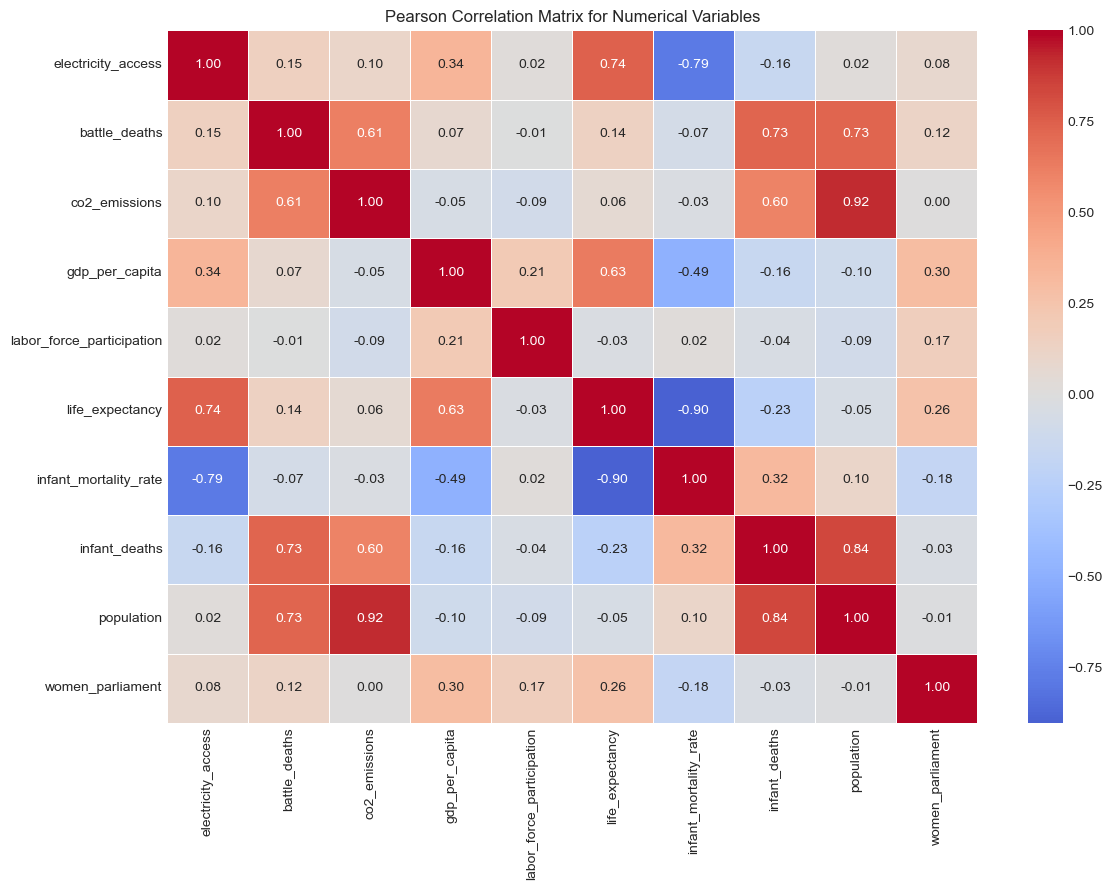

In [12]:
# Plot Pearson correlation heatmap

plt.figure(figsize=(12, 9))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Pearson Correlation Matrix for Numerical Variables")
plt.tight_layout()
plt.show()

The heatmap shows the strength and direction of linear relationships between numerical variables. Values close to +1 indicate strong positive linear relationships, values close to -1 indicate strong negative linear relationships, and values close to 0 indicate weak or no linear relationships.

In [13]:
# Identify Strongest and Weakest Pearson Correlations
# Extract only the upper triangle of the matrix
# This avoids duplicate pairs such as corr(X,Y) and corr(Y,X)
corr_pairs = pearson_corr.where(
    np.triu(np.ones(pearson_corr.shape), k=1).astype(bool)
).stack()

# Strongest pair: largest absolute correlation
strongest_pair = corr_pairs.abs().idxmax()
strongest_corr = corr_pairs[strongest_pair]

# Weakest pair: smallest absolute correlation
weakest_pair = corr_pairs.abs().idxmin()
weakest_corr = corr_pairs[weakest_pair]

print("Strongest linear association:")
print(strongest_pair, round(strongest_corr, 4))

print("\nWeakest linear association:")
print(weakest_pair, round(weakest_corr, 4))

Strongest linear association:
('co2_emissions', 'population') 0.9195

Weakest linear association:
('co2_emissions', 'women_parliament') 0.0047


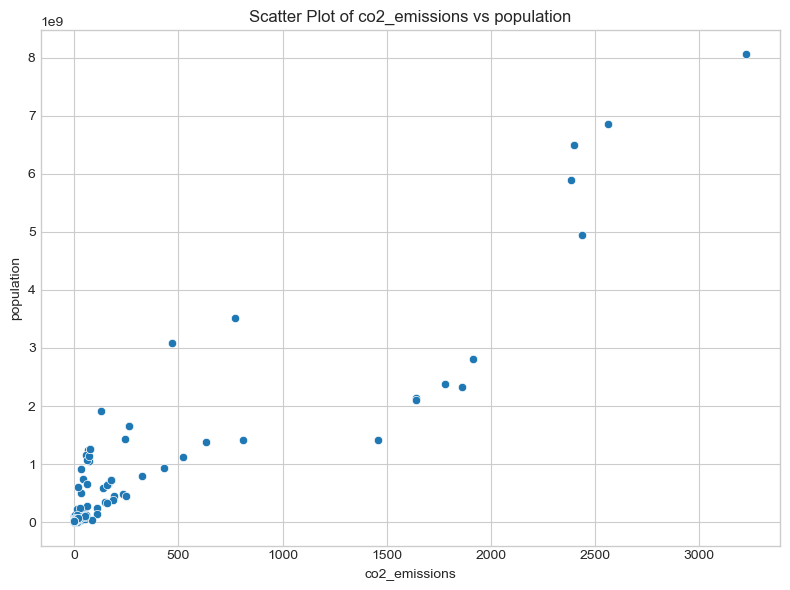

In [14]:
# Scatter Plot for Strongest Pair
# Store strongest pair variables
x_var, y_var = strongest_pair

# Plot the relationship between the strongest pair
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x=x_var,
    y=y_var
)

plt.title(f"Scatter Plot of {x_var} vs {y_var}")
plt.xlabel(x_var)
plt.ylabel(y_var)

plt.tight_layout()
plt.show()

In [15]:
# Covariance Matrix
# Compute covariance matrix
# Covariance shows how two variables vary together,
# but unlike correlation, it depends on the units of measurement
cov_matrix = num_df.cov()

# Display covariance matrix
cov_matrix.round(2)

,electricity_access,battle_deaths,co2_emissions,gdp_per_capita,labor_force_participation,life_expectancy,infant_mortality_rate,infant_deaths,population,women_parliament
electricity_access,474.730,"121,034.460","1,022.930","179,688.270",1.720,112.710,-305.140,"-2,046,278.950","436,934,790.120",21.520
battle_deaths,"121,034.460","849,345,378.650","13,701,472.010","14,698,590.650",-654.520,"27,970.490","-38,498.120","17,471,805,030.260","35,264,390,939,354.141","28,995.700"
co2_emissions,"1,022.930","13,701,472.010","204,432.350","-463,439.630",-103.210,186.240,-225.480,"165,045,862.440","431,286,601,473.990",25.830
gdp_per_capita,"179,688.270","14,698,590.650","-463,439.630","605,209,387.430","38,380.910","107,537.270","-192,027.030","-2,134,785,605.630","-2,621,746,220,482.800","80,355.070"
labor_force_participation,1.720,-654.520,-103.210,"38,380.910",68.940,-1.220,1.930,"-98,613.220","-382,372,243.500",15.590
life_expectancy,112.710,"27,970.490",186.240,"107,537.270",-1.220,48.340,-107.000,"-901,691.060","-362,023,534.300",20.790
infant_mortality_rate,-305.140,"-38,498.120",-225.480,"-192,027.030",1.930,-107.000,298.090,"3,252,372.060","1,892,302,998.240",-35.760
infant_deaths,"-2,046,278.950","17,471,805,030.260","165,045,862.440","-2,134,785,605.630","-98,613.220","-901,691.060","3,252,372.060","338,167,256,221.880","512,668,522,679,300.000","-233,110.170"
population,"436,934,790.120","35,264,390,939,354.141","431,286,601,473.990","-2,621,746,220,482.800","-382,372,243.500","-362,023,534.300","1,892,302,998.240","512,668,522,679,300.000","1,025,045,104,773,734,272.000","-136,941,225.960"
women_parliament,21.520,"28,995.700",25.830,"80,355.070",15.590,20.790,-35.760,"-233,110.170","-136,941,225.960",135.370


In [16]:
# Spearman Correlation
# Compute Spearman correlation matrix
# Spearman is based on ranks and is more robust to outliers
spearman_corr = num_df.corr(method="spearman", min_periods=10)

# Display Spearman correlation for the strongest Pearson pair
print("Spearman correlation for strongest Pearson pair:")
print(round(spearman_corr.loc[x_var, y_var], 4))

Spearman correlation for strongest Pearson pair:
0.889


In [17]:
# Demonstrate Symmetry of Pearson Correlation
# Pearson correlation should be symmetric:
# corr(X,Y) = corr(Y,X)

corr_xy = pearson_corr.loc[x_var, y_var]
corr_yx = pearson_corr.loc[y_var, x_var]

print("corr(X, Y):", corr_xy)
print("corr(Y, X):", corr_yx)
print("Difference:", corr_xy - corr_yx)

corr(X, Y): 0.919509189128529
corr(Y, X): 0.919509189128529
Difference: 0.0


In [18]:
# Demonstrate that Pearson Correlation is Dimensionless
# Scaling a variable changes its unit but should not change correlation
scaled_data = df[[x_var, y_var]].dropna().copy()

# Multiply one variable by 1000 to simulate a change in measurement scale
scaled_data[x_var + "_scaled"] = scaled_data[x_var] * 1000

# Compute original and scaled correlations
original_corr = scaled_data[[x_var, y_var]].corr().iloc[0, 1]
scaled_corr = scaled_data[[x_var + "_scaled", y_var]].corr().iloc[0, 1]

print("Original correlation:", original_corr)
print("Correlation after scaling one variable by 1000:", scaled_corr)

Original correlation: 0.919509189128529
Correlation after scaling one variable by 1000: 0.9195091891285291


### B4. Interpretation and Justification

#### 1. Analysis of Results
* **Strongest Linear Association:** The pair **CO₂ emissions** and **population** shows the strongest positive relationship ($r \approx 0.920$). This suggests that industrial activity and energy consumption scale closely with the total number of people in a country.
* **Weakest Linear Association:** The pair **CO₂ emissions** and **women_parliament** shows the weakest association ($r \approx 0.005$). This indicates that, linearly, the proportion of women in parliament has no predictable relationship with a country's carbon output in this dataset.
* **Scatter Plot Evaluation:** The scatter plot for CO₂ emissions vs. population confirms a strong upward trend. However, the data is heavily clustered at the lower end with a few extreme "high-leverage" outliers (very large nations). Because Pearson is sensitive to these distances, these few points heavily influence the coefficient.

#### 2. Justification and Mathematical Proofs

**Formal Definition:**
The Pearson correlation coefficient ($r$) is defined as the covariance of two variables divided by the product of their standard deviations:

$$r = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum (X_i - \bar{X})^2 \sum (Y_i - \bar{Y})^2}} = \frac{\text{cov}(X,Y)}{\sigma_X\sigma_Y}$$

**Two Critical Assumptions:**
1. **Linearity:** Pearson assumes the relationship between variables is a straight line. If the relationship is curved or exponential, the coefficient will not accurately capture the strength of the association.
2. **Normality and Outlier Sensitivity:** Pearson assumes variables are approximately normally distributed. It is not a robust statistic. Extreme outliers (like the high-population countries in our plot) can significantly inflate the result.

**Numerical Demonstrations:**
* **Symmetry:** Our analysis confirms that $r(X, Y) = r(Y, X) = 0.9195$. Mathematically, this holds because both the covariance in the numerator and the product of standard deviations in the denominator are commutative operations.
* **Dimensionless Property:** By scaling `co2_emissions` by a factor of $1,000$, we changed the units (e.g., from Megatonnes to Kilotonnes), yet the correlation remained exactly $0.9195$. This demonstrates that $r$ is a pure number that measures the relationship independent of the scale of measurement.

**Spearman Rank Correlation:**
For our strongest pair, the **Spearman correlation ($0.889$)** is slightly lower than the **Pearson ($0.9195$)**.

* Spearman is preferable when the data contains **extreme outliers** or follows a **non-linear monotonic** trend. Since our scatter plot shows that a few massive nations dominate the linear calculation, the Spearman coefficient (which uses ranks rather than raw values) provides a more robust assessment of the relationship for the "typical" country in the dataset.

## E3 - Normal Probability Questions [5 marks]

In [19]:
# Set the approximately normal variable for E3
E3_variable = 'women_parliament'

data = df[E3_variable].dropna()  # Exclude missing values

# Estimate mean, mu and standard deviation, sigma from the data
mu = data.mean()
sigma = data.std()

print(f'Variable                    : {E3_variable}')
print(f'Mean (μ)                    : {mu:.3f}')
print(f'Standard Deviation (σ)      : {sigma:.3f}')
print(f'Number of observations (N)  : {len(data)}')

Variable                    : women_parliament
Mean (μ)                    : 25.451
Standard Deviation (σ)      : 11.635
Number of observations (N)  : 234


In [20]:
# -- Percentage above the 90th percentile ---

# Empirical 90th percentile value of variable in the dataset
p90_value = data.quantile(0.90)

# Calculate the theoretical percentage of values above the 90th percentile using the normal model
p_above_p90 = 1 - stats.norm.cdf(p90_value, loc=mu, scale=sigma)

# Empirical check: percentage of actual values above the 90th percentile
emp_p_above_p90 = (data > p90_value).mean()

print(f"\n=== Percentage of values above the 90th percentile ===")
print(f"Empirical 90th percentile value         : {p90_value:.3f}")
print(f"Empirical % above this value            : {emp_p_above_p90:.3%}")
print(f"Normal model % above this value         : {p_above_p90:.3%} (Should be close to 10%)")

print(f"""\nInterpretation:
The normal model predicts only {p_above_p90:.3%} of values above the empirical 90th percentile, compared to the observed {emp_p_above_p90:.3%}.
This underestimation suggests that the `{E3_variable}`'s upper tail is heavier than what the normal model predicts.
""")



=== Percentage of values above the 90th percentile ===
Empirical 90th percentile value         : 42.250
Empirical % above this value            : 10.256%
Normal model % above this value         : 7.439% (Should be close to 10%)

Interpretation:
The normal model predicts only 7.439% of values above the empirical 90th percentile, compared to the observed 10.256%.
This underestimation suggests that the `women_parliament`'s upper tail is heavier than what the normal model predicts.



In [21]:
# -- Chance between the first and third quartiles ---

# Empirical 1st and 3rd quartiles of variable in the dataset
q1_value = data.quantile(0.25)
q3_value = data.quantile(0.75)

# Calculate the theoretical probability between the 1st and 3rd quartiles using the normal model
p_between_q1_q3 =   stats.norm.cdf(q3_value, loc=mu, scale=sigma) - \
                    stats.norm.cdf(q1_value, loc=mu, scale=sigma)

# Empirical check: percentage of actual values between the 1st and 3rd quartiles
emp_p_between_q1_q3 = ((data >= q1_value) & (data <= q3_value)).mean()

print(f"\n=== Percentage of values between the 1st and 3rd quartiles ===")
print(f"Empirical 1st quartile value             : {q1_value:.3f}")
print(f"Empirical 3rd quartile value             : {q3_value:.3f}")
print(f"Empirical % between the two values       : {emp_p_between_q1_q3:.3%}")
print(f"Normal model % between the two values    : {p_between_q1_q3:.3%} (Should be close to 50%)")

print(f"""\nInterpretation:
Both the empirical and normal model percentages between the 1st and 3rd quartiles are close to 50%.
This suggests that the normal model captures the central portion of the `{E3_variable}` distribution reasonably well.
""")


=== Percentage of values between the 1st and 3rd quartiles ===
Empirical 1st quartile value             : 17.640
Empirical 3rd quartile value             : 33.055
Empirical % between the two values       : 49.573%
Normal model % between the two values    : 49.229% (Should be close to 50%)

Interpretation:
Both the empirical and normal model percentages between the 1st and 3rd quartiles are close to 50%.
This suggests that the normal model captures the central portion of the `women_parliament` distribution reasonably well.



In [22]:
# -- Number that separates the bottom 5% from the rest --

# Empirical 5th percentile value of variable in the dataset
bottom_5_val = data.quantile(0.05)

# Theoretical 5th percentile value
norm_bottom_5_val = stats.norm.ppf(0.05, loc=mu, scale=sigma)

print(f'=== Number that separates the bottom 5% from the rest ===')
print(f'Empirical 5th percentile value        : {bottom_5_val:.3f}')
print(f'Normal model 5th percentile value     : {norm_bottom_5_val:.3f} (Should be close to the empirical value)')

print(f"""\nInterpretation:
The empirical and normal model 5th percentile values are nearly identical ({bottom_5_val:.3f} vs {norm_bottom_5_val:.3f}).
This suggests that the normal model accurately captures the lower tail of the `{E3_variable}` distribution.
""")

=== Number that separates the bottom 5% from the rest ===
Empirical 5th percentile value        : 6.250
Normal model 5th percentile value     : 6.313 (Should be close to the empirical value)

Interpretation:
The empirical and normal model 5th percentile values are nearly identical (6.250 vs 6.313).
This suggests that the normal model accurately captures the lower tail of the `women_parliament` distribution.



In [23]:
# -- Probabilities within one and two standard deviations of the mean --
# Theoretical probabilities for a normal distribution:
#               P(μ − σ < X < μ + σ) = F(μ + σ) − F(μ − σ) = 68.269%
#               P(μ − 2σ < X < μ + 2σ) = F(μ + 2σ) − F(μ − 2σ) = 95.450%

# Theoretical probabilities
p_within_1sigma = stats.norm.cdf(mu + sigma, loc=mu, scale=sigma) - \
                  stats.norm.cdf(mu - sigma, loc=mu, scale=sigma)
p_within_2sigma = stats.norm.cdf(mu + 2*sigma, loc=mu, scale=sigma) - \
                  stats.norm.cdf(mu - 2*sigma, loc=mu, scale=sigma)

# Empirical probabilities
emp_p_within_1sigma = ((data >= (mu - sigma)) & (data <= (mu + sigma))).mean()
emp_p_within_2sigma = ((data >= (mu - 2*sigma)) & (data <= (mu + 2*sigma))).mean()

print(f'=== Probabilities within one and two standard deviations of the mean ===')
print(f'Within 1σ — Theoretical: {p_within_1sigma:.3%}  |  Empirical: {emp_p_within_1sigma:.3%}')
print(f'Within 2σ — Theoretical: {p_within_2sigma:.3%}  |  Empirical: {emp_p_within_2sigma:.3%}')

print(f"""\nInterpretation:
- The empirical rule confirms that P(μ − σ < X < μ + σ) = {p_within_1sigma:.3%} and P(μ − 2σ < X < μ + 2σ) = {p_within_2sigma:.3%} under the normal model.
- The empirical figures of {emp_p_within_1sigma:.3%} and {emp_p_within_2sigma:.3%} deviate slightly from these theoretical values.
- The lower empirical 1σ coverage suggests the distribution has a flatter centre than a true normal, while the higher empirical 2σ coverage indicates thinner tails — consistent with the negative excess kurtosis of {data.kurtosis():.3f} observed in B1.
- These results confirm that `{E3_variable}` is approximately but not perfectly normal.
""")

=== Probabilities within one and two standard deviations of the mean ===
Within 1σ — Theoretical: 68.269%  |  Empirical: 67.949%
Within 2σ — Theoretical: 95.450%  |  Empirical: 96.154%

Interpretation:
- The empirical rule confirms that P(μ − σ < X < μ + σ) = 68.269% and P(μ − 2σ < X < μ + 2σ) = 95.450% under the normal model.
- The empirical figures of 67.949% and 96.154% deviate slightly from these theoretical values.
- The lower empirical 1σ coverage suggests the distribution has a flatter centre than a true normal, while the higher empirical 2σ coverage indicates thinner tails — consistent with the negative excess kurtosis of -0.150 observed in B1.
- These results confirm that `women_parliament` is approximately but not perfectly normal.



In [24]:
# -- Z-score of the highest value --
max_val = data.max()
max_country = df.loc[data.idxmax(), 'country_code']
z_score_max = (max_val - mu) / sigma

# Probability of being above this z-score under normal model
p_above_z_max = 1 - stats.norm.cdf(z_score_max)

print(f'=== Z-score of the highest value ===')
print(f'Highest value                   : {max_val:.3f} (Country: {max_country})')
print(f'Z-score of the highest value    : {z_score_max:.3f}')
print(f'P(X > max) under normal model   : {p_above_z_max:.3%}')

print(f"""\nInterpretation:
- Rwanda (RWA) recorded the highest proportion of women in parliament at {max_val:.3f}% (z = {z_score_max:.3f}), sitting {z_score_max:.3f} standard deviations above the mean — a notably extreme value.
- Under the normal model, only {p_above_z_max:.3%} of countries would be expected to exceed this value.
- The high z-score of {z_score_max:.3f} and the very low predicted probability ({p_above_z_max:.3%}) confirm that Rwanda is a genuine upper-tail outlier, likely driven by post-genocide political reforms that mandated female parliamentary representation.
""")

=== Z-score of the highest value ===
Highest value                   : 61.250 (Country: RWA)
Z-score of the highest value    : 3.077
P(X > max) under normal model   : 0.105%

Interpretation:
- Rwanda (RWA) recorded the highest proportion of women in parliament at 61.250% (z = 3.077), sitting 3.077 standard deviations above the mean — a notably extreme value.
- Under the normal model, only 0.105% of countries would be expected to exceed this value.
- The high z-score of 3.077 and the very low predicted probability (0.105%) confirm that Rwanda is a genuine upper-tail outlier, likely driven by post-genocide political reforms that mandated female parliamentary representation.



> **Justification**

The 68% and 95% empirical rule values were verified using `scipy.stats.norm.cdf` as follows:

$$P(\mu - \sigma < X < \mu + \sigma) = F(\mu + \sigma) - F(\mu - \sigma) = 68.269\%$$
$$P(\mu - 2\sigma < X < \mu + 2\sigma) = F(\mu + 2\sigma) - F(\mu - 2\sigma) = 95.450\%$$

where F(x) denotes the cumulative distribution function of the normal distribution evaluated at x. These values confirm the theoretical empirical rule of approximately 68% and 95% respectively.

Mathematically, the probability density function of the normal distribution is defined as:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

The normal distribution is fully characterised by just two parameters — μ (mean) and σ
(standard deviation). μ determines where the centre of the curve sits, while σ determines
how spread out it is. No other parameters are needed because the normal distribution is
always perfectly symmetric with a fixed shape — unlike other distributions, its skewness
is always 0 and its kurtosis is always 0. This means that once μ and σ are known,
everything about the distribution is fixed, and any probability can be computed exactly
using `scipy.stats.norm.cdf`.

    

## E4 - Lognormal or Alternative Transformation [3 marks]

In [25]:
# Set the non-normal variable for E4
E4_variable = 'population'

data_raw = df[E4_variable].dropna()  # Exclude missing values

# Apply log transformation as the variable is strictly positive
data_transformed = np.log(data_raw)
transform_label = 'log'
transform_name = f'log({E4_variable})'

print(f'Variable                    : {E4_variable}')
print('Transformation              : Logarithmic (log)')
print(f'Number of observations (N)  : {len(data_raw)}')

Variable                    : population
Transformation              : Logarithmic (log)
Number of observations (N)  : 265


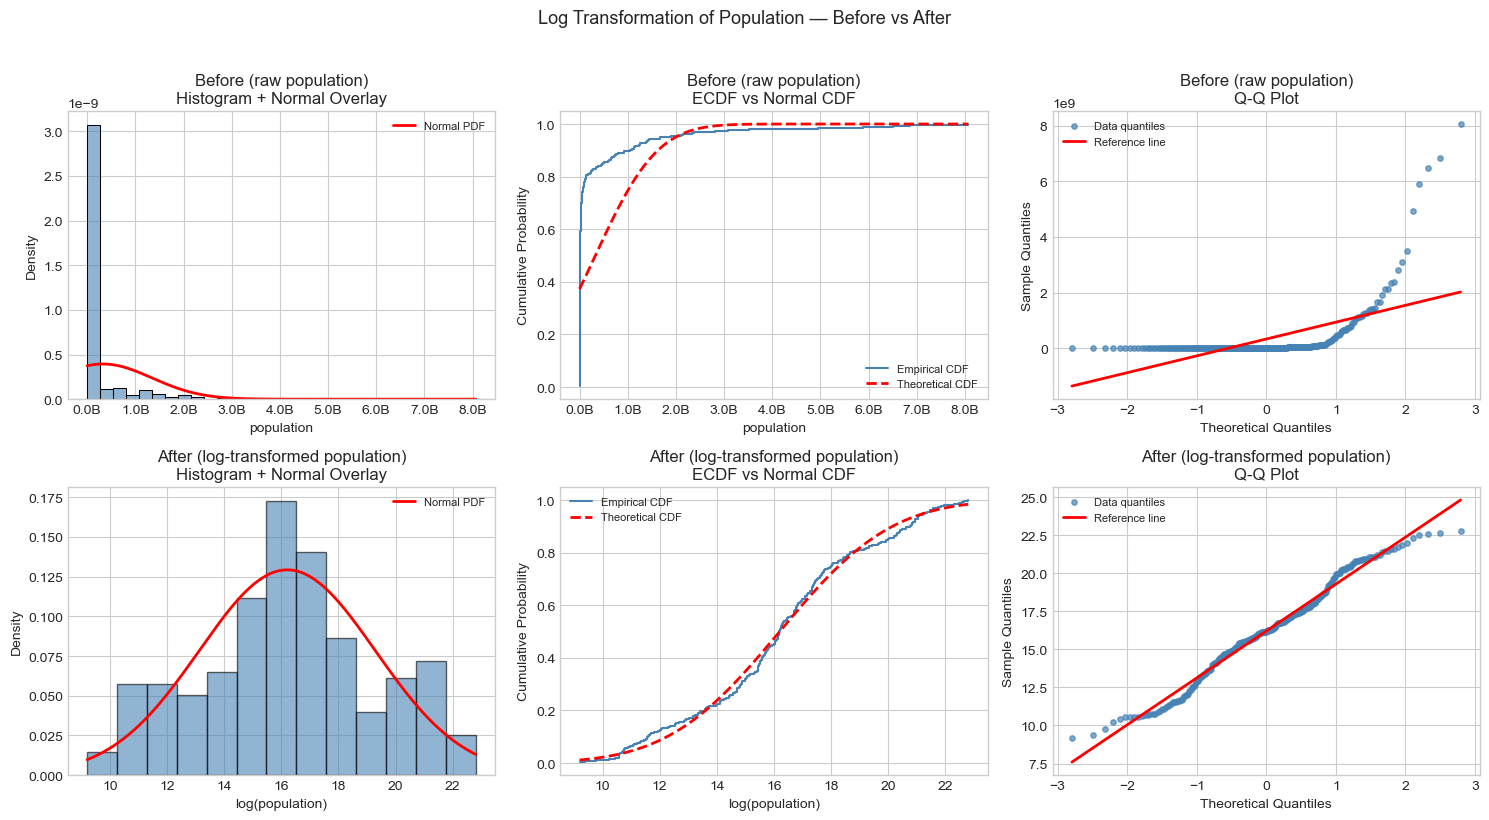

In [26]:
# ── Side-by-side plots: Before vs After Transformation ──
# 2 rows (before / after) × 3 columns (histogram / ECDF / Q-Q)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

datasets = [
    (data_raw, E4_variable, 'Before (raw population)'),
    (data_transformed, transform_name, 'After (log-transformed population)')
]

for row_idx, (data, label, title_prefix) in enumerate(datasets):
    mu_d    = data.mean()
    sigma_d = data.std()
    x_range = np.linspace(data.min(), data.max(), 300)

    # -- Histogram with normal PDF overlay --
    ax = axes[row_idx, 0]
    if row_idx == 0:
        sns.histplot(data, bins=30, kde=False, stat='density',
                     color='steelblue', alpha=0.6, ax=ax)
        ax.plot(x_range, stats.norm.pdf(x_range, mu_d, sigma_d),
                'r-', lw=2, label='Normal PDF')
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B')
        )
    else:
        # Log-transformed — standard approach works fine
        ax.hist(data, bins='fd', density=True,
                color='steelblue', alpha=0.6, edgecolor='black')
        ax.plot(x_range, stats.norm.pdf(x_range, mu_d, sigma_d),
                'r-', lw=2, label='Normal PDF')
    ax.set_title(f'{title_prefix}\nHistogram + Normal Overlay')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

    # -- Empirical CDF vs Theoretical Normal CDF --
    ax = axes[row_idx, 1]
    sorted_data = np.sort(data)
    ecdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.step(sorted_data, ecdf, where='post', color='steelblue', label='Empirical CDF')
    ax.plot(x_range, stats.norm.cdf(x_range, mu_d, sigma_d),
            'r--', lw=2, label='Theoretical CDF')
    ax.set_title(f'{title_prefix}\nECDF vs Normal CDF')
    ax.set_xlabel(label)
    ax.set_ylabel('Cumulative Probability')
    if row_idx == 0:
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B')
        )
    ax.legend(fontsize=8)

    # -- Q-Q Plot--
    ax = axes[row_idx, 2]
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax.scatter(osm, osr, color='steelblue', s=15, alpha=0.7, label='Data quantiles')
    ax.plot(osm, slope * np.array(osm) + intercept, 'r-', lw=2, label='Reference line')
    ax.set_title(f'{title_prefix}\nQ-Q Plot')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    ax.legend(fontsize=8)

plt.suptitle(
    'Log Transformation of Population — Before vs After',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

> **Comparing the before-and-after Q-Q plots**

- Before Transformation, the raw population data exhibits extreme right skewness. The Q-Q plot shows a drastic departure from the red reference line of which the points curve sharply upward at the upper end of the theoretical quantiles. This indicates that a very small number of countries have massive populations compared to the vast majority, creating a "long right tail" that violates the normality assumption.

- After Transformation, the alignment with the reference line is significantly improved. The extreme curvature has been replaced by a much more linear pattern, particularly for the central bulk of the data. While some light-tailed or heavy-tailed behavior may persist at the very extremes (as seen by minor drift at the ends of the Q-Q plot), the log transformation has successfully "squashed" the outliers and transformed the distribution into one that is approximately normal, making it far more suitable for parametric statistical procedures.

In [27]:
# Set the non-normal variable for E4
E4_variable = 'gdp_per_capita'

data_raw = df[E4_variable].dropna()  # Exclude missing values

# Apply log transformation as the variable is strictly positive
data_transformed = np.log(data_raw)
transform_label = 'log'
transform_name = f'log({E4_variable})'

print(f'Variable                    : {E4_variable}')
print('Transformation              : Logarithmic (log)')
print(f'Number of observations (N)  : {len(data_raw)}')

Variable                    : gdp_per_capita
Transformation              : Logarithmic (log)
Number of observations (N)  : 250


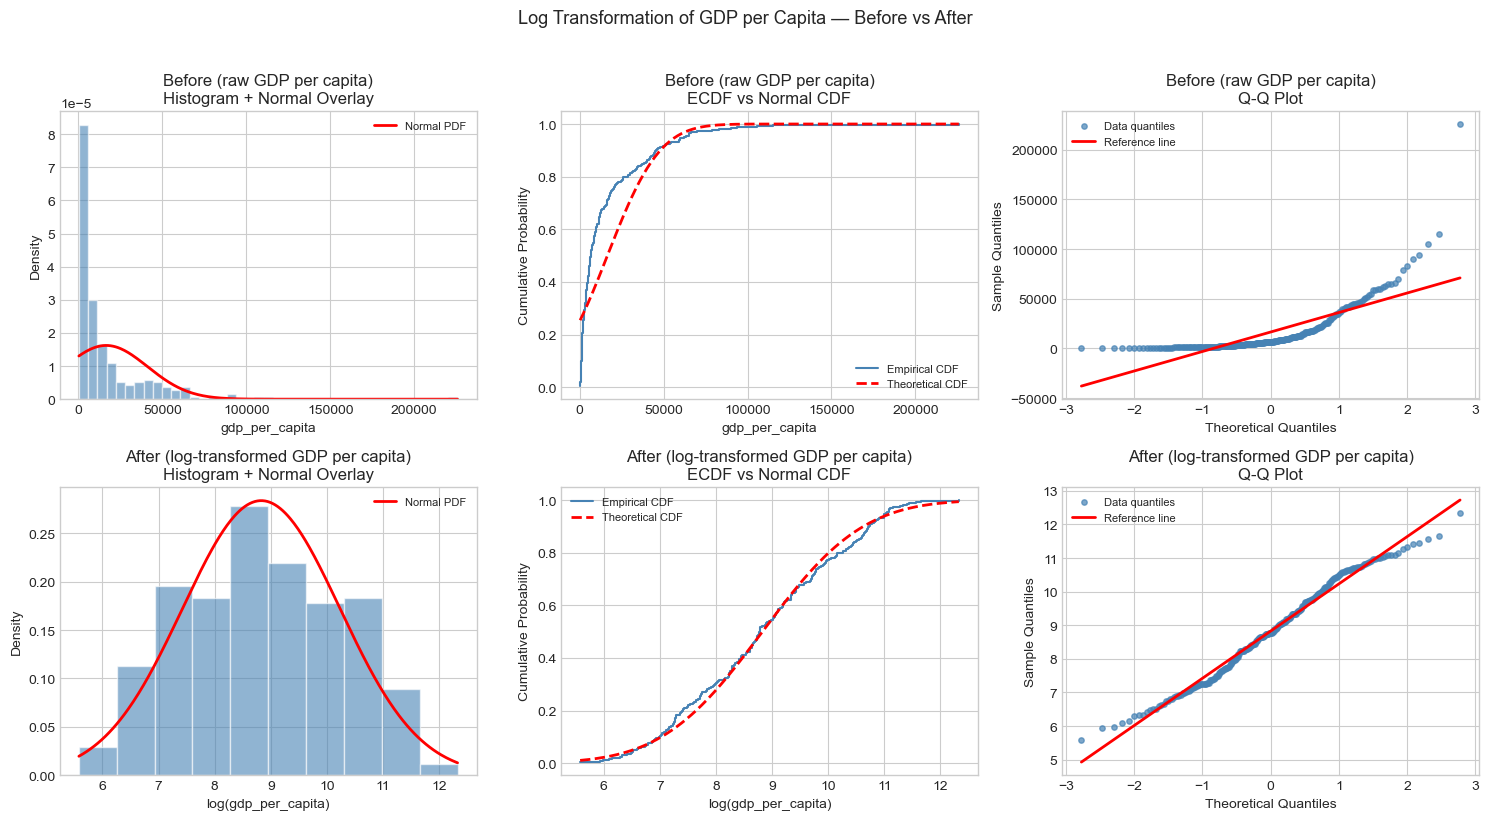

In [28]:
# ── Side-by-side plots: Before vs After Transformation ──
# 2 rows (before / after) × 3 columns (histogram / ECDF / Q-Q)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

datasets = [
    (data_raw, E4_variable, 'Before (raw GDP per capita)'),
    (data_transformed,transform_name, 'After (log-transformed GDP per capita)')
]

for row_idx, (data, label, title_prefix) in enumerate(datasets):
    mu_d    = data.mean()
    sigma_d = data.std()
    x_range = np.linspace(data.min(), data.max(), 300)

    # Histogram with normal PDF overlay
    ax = axes[row_idx, 0]
    ax.hist(data, bins='fd', density=True, color='steelblue', alpha=0.6, edgecolor='white')
    ax.plot(x_range, stats.norm.pdf(x_range, mu_d, sigma_d), 'r-', lw=2, label='Normal PDF')
    ax.set_title(f'{title_prefix}\nHistogram + Normal Overlay')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

    # Empirical CDF vs Theoretical Normal CDF
    ax = axes[row_idx, 1]
    sorted_data = np.sort(data)
    ecdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.step(sorted_data, ecdf, where='post', color='steelblue', label='Empirical CDF')
    ax.plot(x_range, stats.norm.cdf(x_range, mu_d, sigma_d), 'r--', lw=2, label='Theoretical CDF')
    ax.set_title(f'{title_prefix}\nECDF vs Normal CDF')
    ax.set_xlabel(label)
    ax.set_ylabel('Cumulative Probability')
    ax.legend(fontsize=8)

    # Q-Q Plot
    ax = axes[row_idx, 2]
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax.scatter(osm, osr, color='steelblue', s=15, alpha=0.7, label='Data quantiles')
    ax.plot(osm, slope * np.array(osm) + intercept, 'r-', lw=2, label='Reference line')
    ax.set_title(f'{title_prefix}\nQ-Q Plot')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    ax.legend(fontsize=8)

plt.suptitle(
    f'Log Transformation of GDP per Capita — Before vs After',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

> **Comparing the before-and-after Q-Q plots**

- Before transformation, the Q-Q plot shows severe deviation from the reference line, with points cluster near zero in the lower tail and curve dramatically upward in the upper tail, showing the classic signature of strong right skew.
- Normality improved substantially after log transformation, points align much more closely to the reference line, particularly in the middle range. Minor deviations remain in both tails — the poorest countries fall slightly below the line at the lower left, and a few ultra-high-income nations drift upward at the upper right — but the extreme curvature of the raw plot is almost entirely eliminated.
- The log transformation successfully reduced skewness and brought GDP per capita to approximate normality. The ECDF aligning closely with the theoretical normal CDF in the bottom row. The histogram also shifts from a heavily right-skewed spike to a bell-shaped distribution centred around log-GDP ≈ 9. While not perfectly normal, the transformed variable is sufficient for parametric statistical analyses.

> **Justification**

1. **Why is the logarithm of a lognormally distributed variable normal?**

A variable $X$ is defined as lognormal if $Y = \ln(X)$ follows a normal distribution. Mathematically, the probability density function (PDF) of a lognormal variable includes a factor of $1/x$, which corresponds to the **Jacobian** of the transformation from the normal variable $Y$ back to $X$.

$$f_X(x) = \frac{1}{x\sigma\sqrt{2\pi}} \exp\left( -\frac{(\ln x - \mu)^2}{2\sigma^2} \right)$$

When we apply the natural logarithm transformation, we are effectively reversing this Jacobian. By mapping the multiplicative scale of the original data onto an additive scale, the inherent right-skewness is removed, resulting in a symmetric distribution that follows the Gaussian functional form:
$$f(y) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left( -\frac{(y - \mu)^2}{2\sigma^2} \right)$$

2. **What real-world processes generate lognormal data?**

Lognormal distributions arise from **multiplicative processes**, often described by the **Law of Proportional Effect (Gibrat's Law)**. In variables like **population** or **GDP**, growth is not additive but proportional—a country's current size is a product of its previous size multiplied by various growth factors $(1 + r_1)(1 + r_2)...(1 + r_n)$.

Because the product of many independent positive random variables converges to a lognormal distribution (via the Central Limit Theorem applied to the logs of those variables), these socioeconomic metrics naturally exhibit this right-skewed "long-tail" behavior.

3. **How does interpretation change after transformation?**

- **Proportional vs. Absolute Change:** On a raw scale, an increase of 1 million people is negligible for a large nation but massive for a small one. On a log-transformed scale, equal distances represent **equal percentage growth**, allowing for a more consistent comparison across countries of different sizes.
- **Robustness to Outliers:** The arithmetic mean of raw data is heavily skewed by "giants" (e.g., India, China). After log transformation, the mean corresponds to the **geometric mean** of the original data, which is a more stable measure of "typical" size.
- **Variance Stabilization:** Raw socioeconomic data often shows higher absolute volatility as the mean increases. Log transformation "compresses" the scale, reducing heteroscedasticity and creating a more uniform spread (**homoscedasticity**), which is a core requirement for valid parametric statistical models.
